In [2]:
import matplotlib.pyplot as plt
import numpy as np

from auv_planning.oscar_loader import load_oscar_region


In [ ]:
from pathlib import Path

history_dir = Path("../data/raw/oscar_history")

files = sorted(history_dir.glob("*.nc"))

print(f"Found {len(files)} OSCAR files")
print("Using:", files[-1])

grid = load_oscar_region(
    files[-1],
    min_lat=32,
    max_lat=38,
    min_lon=-126,
    max_lon=-120,
)


print("Grid:", grid.current_u.shape)
print("Usable ocean cells:", grid.traversable.sum())

Grid: (25, 25)
Usable ocean cells: 516


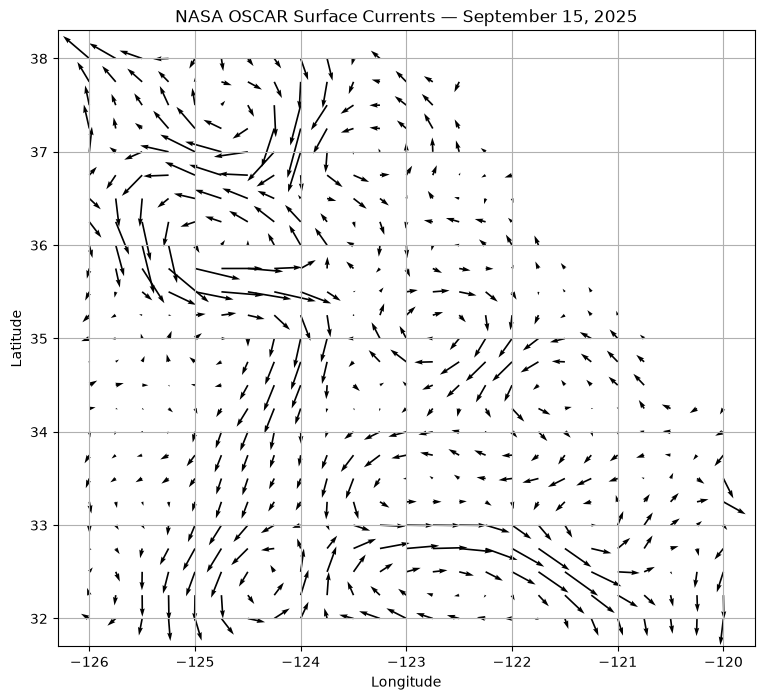

In [4]:
lon, lat = np.meshgrid(
    grid.longitudes,
    grid.latitudes,
)

u = np.where(
    grid.traversable,
    grid.current_u,
    np.nan,
)

v = np.where(
    grid.traversable,
    grid.current_v,
    np.nan,
)

plt.figure(figsize=(9, 8))

plt.quiver(
    lon,
    lat,
    u,
    v,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NASA OSCAR Surface Currents — September 15, 2025")
plt.grid()

plt.show()

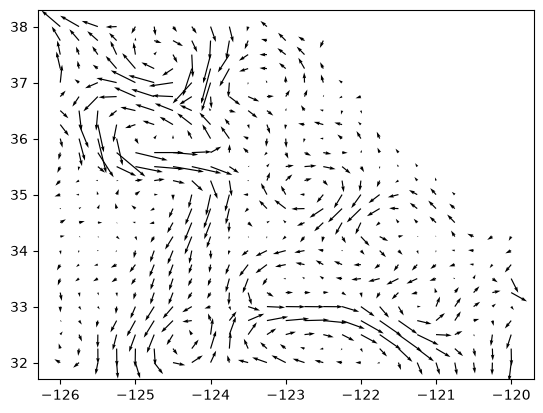

In [5]:
plt.quiver(lon, lat, u, v)

In [6]:
# Show the grid indices corresponding to some usable ocean cells.
for y in range(grid.height):
    for x in range(grid.width):
        if grid.traversable[y, x]:
            if x % 6 == 0 and y % 6 == 0:
                print(
                    (x, y),
                    "→",
                    f"({grid.latitudes[y]:.2f}, "
                    f"{grid.longitudes[x]:.2f})"
                )

(0, 0) → (32.00, -126.00)
(6, 0) → (32.00, -124.50)
(12, 0) → (32.00, -123.00)
(18, 0) → (32.00, -121.50)
(24, 0) → (32.00, -120.00)
(0, 6) → (33.50, -126.00)
(6, 6) → (33.50, -124.50)
(12, 6) → (33.50, -123.00)
(18, 6) → (33.50, -121.50)
(24, 6) → (33.50, -120.00)
(0, 12) → (35.00, -126.00)
(6, 12) → (35.00, -124.50)
(12, 12) → (35.00, -123.00)
(18, 12) → (35.00, -121.50)
(0, 18) → (36.50, -126.00)
(6, 18) → (36.50, -124.50)
(12, 18) → (36.50, -123.00)
(0, 24) → (38.00, -126.00)
(6, 24) → (38.00, -124.50)


In [7]:
from auv_planning.astar import astar
from auv_planning.current_aware_astar import current_aware_astar

start = (0, 6)
goal = (18, 6)

shortest_path = astar(grid, start, goal)

energy_path = current_aware_astar(
    grid,
    start,
    goal,
    ground_speed=1.0,
    power_coefficient=200.0,
)

print("Shortest path:", shortest_path)
print("Energy-aware path:", energy_path)

print("\nShortest path cells:", len(shortest_path))
print("Energy-aware path cells:", len(energy_path))

Shortest path: [(0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (12, 6), (13, 6), (14, 6), (15, 6), (16, 6), (17, 6), (18, 6)]
Energy-aware path: [(0, 6), (0, 5), (1, 4), (2, 3), (3, 2), (4, 1), (5, 0), (6, 0), (7, 0), (8, 1), (9, 2), (10, 3), (11, 3), (12, 3), (13, 3), (14, 3), (15, 3), (16, 3), (17, 3), (18, 3), (19, 4), (19, 5), (18, 6)]

Shortest path cells: 19
Energy-aware path cells: 23


In [8]:
from auv_planning.current_aware_astar import (
    edge_current,
    edge_distance,
    edge_direction,
)
from auv_planning.energy_model import movement_energy


def path_metrics(
    grid,
    path,
    ground_speed=1.0,
    power_coefficient=200.0,
):
    total_distance = 0.0
    total_energy = 0.0

    for current, neighbour in zip(path[:-1], path[1:]):
        distance_m = edge_distance(grid, current, neighbour)
        ocean_current = edge_current(grid, current, neighbour)
        direction = edge_direction(grid, current, neighbour)

        energy = movement_energy(
            current=current,
            neighbour=neighbour,
            current_velocity=ocean_current,
            distance_m=distance_m,
            ground_speed=ground_speed,
            power_coefficient=power_coefficient,
            travel_direction_vector=direction,
        )

        total_distance += distance_m
        total_energy += energy

    return total_distance, total_energy


shortest_distance, shortest_energy = path_metrics(
    grid,
    shortest_path,
)

energy_distance, energy_energy = path_metrics(
    grid,
    energy_path,
)

print(f"Shortest route distance: {shortest_distance / 1000:.1f} km")
print(f"Shortest route energy:   {shortest_energy / 1_000_000:.1f} MJ")

print()

print(f"Energy route distance:   {energy_distance / 1000:.1f} km")
print(f"Energy route energy:     {energy_energy / 1_000_000:.1f} MJ")

print()

print(
    f"Distance increase: "
    f"{(energy_distance / shortest_distance - 1) * 100:.1f}%"
)

print(
    f"Energy savings: "
    f"{(1 - energy_energy / shortest_energy) * 100:.1f}%"
)

Shortest route distance: 417.3 km
Shortest route energy:   105.3 MJ

Energy route distance:   653.2 km
Energy route energy:     75.0 MJ

Distance increase: 56.5%
Energy savings: 28.7%


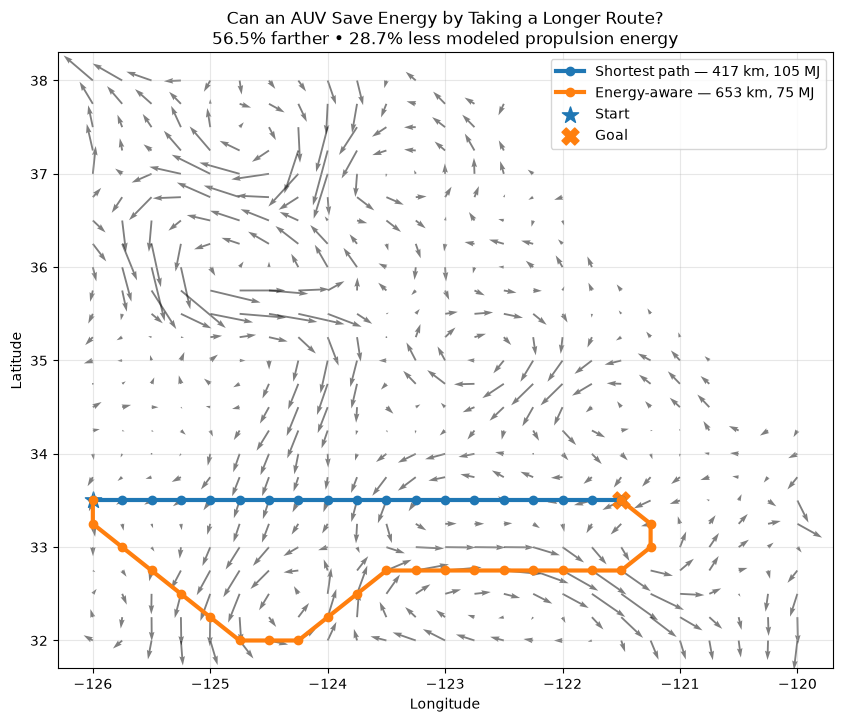

In [9]:
# Convert grid paths into longitude/latitude coordinates
def path_coordinates(grid, path):
    lons = [grid.longitudes[x] for x, y in path]
    lats = [grid.latitudes[y] for x, y in path]
    return lons, lats


shortest_lons, shortest_lats = path_coordinates(grid, shortest_path)
energy_lons, energy_lats = path_coordinates(grid, energy_path)

lon, lat = np.meshgrid(grid.longitudes, grid.latitudes)

u = np.where(grid.traversable, grid.current_u, np.nan)
v = np.where(grid.traversable, grid.current_v, np.nan)

plt.figure(figsize=(10, 8))

# NASA OSCAR current field
plt.quiver(
    lon,
    lat,
    u,
    v,
    alpha=0.5,
)

# Shortest-distance route
plt.plot(
    shortest_lons,
    shortest_lats,
    marker="o",
    linewidth=3,
    label="Shortest path — 417 km, 105 MJ",
)

# Energy-aware route
plt.plot(
    energy_lons,
    energy_lats,
    marker="o",
    linewidth=3,
    label="Energy-aware — 653 km, 75 MJ",
)

# Start and goal
plt.scatter(
    shortest_lons[0],
    shortest_lats[0],
    s=150,
    marker="*",
    label="Start",
)

plt.scatter(
    shortest_lons[-1],
    shortest_lats[-1],
    s=150,
    marker="X",
    label="Goal",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Can an AUV Save Energy by Taking a Longer Route?\n"
    "56.5% farther • 28.7% less modeled propulsion energy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../results/path_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()